In [1]:
import os

# Outdoor weights and the SemanticKITTI root are not in the repo. Point these at
# wherever you unpacked them; the defaults assume they sit under the repo.
#   export OCTREE_DIFF_KITTI_WEIGHTS=/path/to/weights
#   export OCTREE_DIFF_KITTI_DATA=/path/to/semantic-kitti
KITTI_WEIGHTS = os.environ.get("OCTREE_DIFF_KITTI_WEIGHTS", "weights/kitti")
KITTI_DATA = os.environ.get("OCTREE_DIFF_KITTI_DATA", "data/kitti")

from octree_diff.viz.open3d_viewers import visualize_kitti_instance, visualize_structure

from octree_diff.diffusion.util_sample_stuff import *
from octree_diff.octree.util_octree_stuff import *
from octree_diff.octree.util_dualoctree import *

In [2]:
import os
import torch
import torch
import torch.nn.functional as F

def build_ddpm_sampling_buffers(T, device, beta_start=1e-4, beta_end=2e-2):
    """Extend your linear schedule with helpful arrays for sampling."""
    betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32, device=device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]], dim=0)

    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    # posterior q(x_{t-1}|x_t, x0)
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    # clip log var for t=0 (same trick as OpenAI / LDM)
    posterior_log_variance_clipped = torch.log(torch.clamp(posterior_variance, min=1e-20))
    posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)

    sched = {
        "betas": betas,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "alphas_cumprod_prev": alphas_cumprod_prev,
        "sqrt_alphas_cumprod": sqrt_alphas_cumprod,
        "sqrt_one_minus_alphas_cumprod": sqrt_one_minus_alphas_cumprod,
        "sqrt_recip_alphas": sqrt_recip_alphas,
        "posterior_variance": posterior_variance,
        "posterior_log_variance_clipped": posterior_log_variance_clipped,
        "posterior_mean_coef1": posterior_mean_coef1,
        "posterior_mean_coef2": posterior_mean_coef2,
    }
    return sched

def _extract(a, t, x_shape):
    """
    a: [T], t: [B], x_shape: e.g. (B,C,D,H,W)
    returns [B,1,1,1,1] broadcastable to x
    """
    out = a.gather(0, t)
    return out.view(-1, *([1] * (len(x_shape) - 1)))

@torch.no_grad()
def p_mean_variance_eps(model, x_t, t, sched):
    """
    Predict posterior mean & variance using ε-prediction.
    Returns: mean, log_variance, x0_pred
    """
    # eps_theta
    eps_theta = model(x_t, timesteps=t)

    sqrt_alphabar_t = _extract(sched["sqrt_alphas_cumprod"], t, x_t.shape)
    sqrt_one_minus_alphabar_t = _extract(sched["sqrt_one_minus_alphas_cumprod"], t, x_t.shape)

    # x0 prediction from eps
    x0_pred = (x_t - sqrt_one_minus_alphabar_t * eps_theta) / (sqrt_alphabar_t + 1e-8)

    # posterior mean
    c1 = _extract(sched["posterior_mean_coef1"], t, x_t.shape)
    c2 = _extract(sched["posterior_mean_coef2"], t, x_t.shape)
    mean = c1 * x0_pred + c2 * x_t

    # posterior variance (log)
    log_variance = _extract(sched["posterior_log_variance_clipped"], t, x_t.shape)
    return mean, log_variance, x0_pred

@torch.no_grad()
def sample_ddpm(model, sched, shape, T=1000, device="cuda", x_T=None):
    """
    Classic ancestral DDPM sampling (full 1000 steps).
    - model: ε-pred UNet that accepts integer t in [0..T-1]
    - sched: dict from build_ddpm_sampling_buffers(...)
    - shape: (B,C,D,H,W)
    - x_T: optional starting noise [B,C,D,H,W]
    """
    if x_T is None:
        x_t = torch.randn(shape, device=device)
    else:
        x_t = x_T.to(device)

    model.eval()
    for t_int in reversed(range(T)):
        t = torch.full((shape[0],), t_int, device=device, dtype=torch.long)

        mean, log_var, x0_pred = p_mean_variance_eps(model, x_t, t, sched)

        if t_int > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.exp(0.5 * log_var) * noise
        else:
            # final step: return the x_0 estimate (mean is fine too)
            x_t = x0_pred
    return x_t
import torch

def split2splitbig(split: torch.Tensor) -> torch.Tensor:
    """
    Expand an octant-coded grid into a dense grid with a singleton channel.

    Input:
        split: [B, 8, L, L, L]
            Channels 0..7 map to (e/o) along (z, y, x) respectively.

    Output:
        split_big: [B, 1, 2L, 2L, 2L]
    """
    assert split.ndim == 5, f"Expected [B, 8, L, L, L], got {split.shape}"
    B, C, L, H, W = split.shape
    assert C == 8, f"Channel dimension must be 8, got {C}"

    split_big = torch.full((B, 1, 2*L, 2*H, 2*W), -1, dtype=split.dtype, device=split.device)

    # Work on the single output channel
    sb = split_big[:, 0]

    # Fill each octant
    sb[:, 0::2, 0::2, 0::2] = split[:, 0]  # (e,e,e)
    sb[:, 0::2, 0::2, 1::2] = split[:, 1]  # (e,e,o)
    sb[:, 0::2, 1::2, 0::2] = split[:, 2]  # (e,o,e)
    sb[:, 0::2, 1::2, 1::2] = split[:, 3]  # (e,o,o)
    sb[:, 1::2, 0::2, 0::2] = split[:, 4]  # (o,e,e)
    sb[:, 1::2, 0::2, 1::2] = split[:, 5]  # (o,e,o)
    sb[:, 1::2, 1::2, 0::2] = split[:, 6]  # (o,o,e)
    sb[:, 1::2, 1::2, 1::2] = split[:, 7]  # (o,o,o)

    return split_big




import torch

def splitbig2split(split_big: torch.Tensor) -> torch.Tensor:
    """
    Collapse a dense voxel grid back into an octant-coded tensor.

    Accepts:
        [B, 1, 2L, 2L, 2L]  or  [B, 2L, 2L, 2L]
    Returns:
        [B, 8, L, L, L]
    """
    if split_big.ndim == 5:
        B, C, D, H, W = split_big.shape
        assert C == 1, f"Expected channel=1, got {C}"
        sb = split_big[:, 0]
    elif split_big.ndim == 4:
        B, D, H, W = split_big.shape
        sb = split_big
    else:
        raise AssertionError(f"Expected [B,1,2L,2L,2L] or [B,2L,2L,2L], got {split_big.shape}")

    assert D % 2 == 0 and H % 2 == 0 and W % 2 == 0, "Spatial dims must be even"
    L = D // 2

    out = torch.empty((B, 8, L, L, L), dtype=sb.dtype, device=sb.device)
    out[:, 0] = sb[:, 0::2, 0::2, 0::2]  # (e,e,e)
    out[:, 1] = sb[:, 0::2, 0::2, 1::2]  # (e,e,o)
    out[:, 2] = sb[:, 0::2, 1::2, 0::2]  # (e,o,e)
    out[:, 3] = sb[:, 0::2, 1::2, 1::2]  # (e,o,o)
    out[:, 4] = sb[:, 1::2, 0::2, 0::2]  # (o,e,e)
    out[:, 5] = sb[:, 1::2, 0::2, 1::2]  # (o,e,o)
    out[:, 6] = sb[:, 1::2, 1::2, 0::2]  # (o,o,e)
    out[:, 7] = sb[:, 1::2, 1::2, 1::2]  # (o,o,o)
    return out

def save_checkpoint(path, model, optimizer=None, scheduler=None, ema=None,
                    epoch=0, global_step=0, extra: dict | None=None):
    ckpt = {
        "model": model.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
    }
    if optimizer is not None:
        ckpt["optimizer"] = optimizer.state_dict()
    if scheduler is not None:
        ckpt["scheduler"] = scheduler.state_dict()
    if ema is not None:
        # store EMA shadow weights
        ckpt["ema_shadow"] = {k: v.clone().cpu() for k, v in ema.shadow.items()}
        ckpt["ema_decay"] = ema.decay
    if extra:
        ckpt["extra"] = extra
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(ckpt, path)
    print(f"[+] Saved checkpoint to {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None, ema=None,
                    map_location="cpu", strict=True):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model"], strict=strict)
    print(f"[+] Loaded model weights from {path}")

    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
        print("[+] Loaded optimizer state")
    if scheduler is not None and "scheduler" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler"])
        print("[+] Loaded scheduler state")
    if ema is not None and "ema_shadow" in ckpt:
        # ensure keys match; if model changed, set strict=False earlier
        ema.shadow = {k: v.to(next(model.parameters()).device) for k, v in ckpt["ema_shadow"].items()}
        if "ema_decay" in ckpt:
            ema.decay = ckpt["ema_decay"]
        print("[+] Loaded EMA shadow")

    epoch = ckpt.get("epoch", 0)
    global_step = ckpt.get("global_step", 0)
    extra = ckpt.get("extra", {})
    return epoch, global_step, extra
def voxel_to_patch(vox, patch_size=8):
    """
    Input:
        vox: [B, H, W, D] = [B, 128, 128, 32]
    Output:
        [B, H//p, W//p, D, p, p] = [B, 32, 32, 32, 4, 4]
    """
    B, H, W, D = vox.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "Height/Width must be divisible by patch size"

    vox = vox.view(B, H//P, P, W//P, P, D)               # [B, 32, 4, 32, 4, D]
    vox = vox.permute(0, 1, 3, 5, 2, 4)                  # [B, 32, 32, D, 4, 4]
    return vox  # [B, 32, 32, D, 4, 4]
def patch_to_voxel(patches):
    """
    Input:
        patches: [B, 32, 32, 32, 4, 4]
    Output:
        [B, 128, 128, 32]
    """
    B, H, W, D, p1, p2 = patches.shape
    assert p1 == p2, "patch must be square"

    vox = patches.permute(0, 1, 4, 2, 5, 3)              # [B, 32, 4, 32, 4, D]
    vox = vox.reshape(B, H * p1, W * p2, D)              # [B, 128, 128, D]
    return vox
def get_non_empty_mask(vox, patch_size=8):
    """
    Input:
        vox: [128, 128, 32]
    Output:
        mask: [32, 32, 32] (bool), True if corresponding 4x4 patch contains nonzero
    """
    H, W, D = vox.shape
    P = patch_size
    assert H % P == 0 and W % P == 0

    # reshape to group patches
    vox_reshaped = vox.view(H//P, P, W//P, P, D)           # [32, 4, 32, 4, 32]
    vox_reshaped = vox_reshaped.permute(0, 2, 4, 1, 3)     # [32, 32, 32, 4, 4]

    # check if any voxel in each patch is non-zero
    mask = (vox_reshaped != 0).any(dim=(-1, -2))           # [32, 32, 32]
    return mask




In [3]:
from octree_diff.models.semantic.graph_sem_vae import GraphVAE
DEPTH_STOP = 6
LATENT_DIM = 8
FULL_DEPTH = 3
vae = GraphVAE(
    depth=6,
    channel_in=32,     
    nout=2,
    full_depth=FULL_DEPTH,
    depth_stop=DEPTH_STOP ,
    depth_out=6,
    latent_dim=LATENT_DIM,  
    num_classes=21,# latent dimension
    resblk_num=1,
    patch_size=4,   # outdoor uses 4x4 patches; the default 2 will not load these weights
    
).cuda()

vae.load_state_dict(torch.load(f"{KITTI_WEIGHTS}/vae_fdepth6_ldim8_8.pt"),vae.parameters())

vae.eval() 

import torch
from octree_diff.models.semantic.dual_octree import DualOctree
from octree_diff.models.semantic.graph_unet_hr import UNet3DModel

# === 1. Hyperparams ===
in_channels = LATENT_DIM        # dimension of latent z
model_channels = 64

lr_model_channels = 128
out_channels = LATENT_DIM      # same as input if predicting noise
image_size = 16
depth = DEPTH_STOP
full_depth = FULL_DEPTH
channel_mult = [2,4]
num_res_blocks = [2, 2, 2]



# === 4. Init and forward model ===
unet_model = UNet3DModel(
    image_size=image_size,
    input_depth=depth,
    full_depth=full_depth,
    in_channels=in_channels,
    model_channels=model_channels,
    lr_model_channels=lr_model_channels,
    out_channels=out_channels,
    num_res_blocks=num_res_blocks,
    dropout=0.1,
    channel_mult=channel_mult,
    use_checkpoint=False,
).cuda()

unet_model.load_state_dict(torch.load(f"{KITTI_WEIGHTS}/Model_is_good_8_6.pt"),unet_model.parameters())
unet_model.eval()
from octree_diff.models.outdoor.graph_unet_lr import UNet3DModel
batch_size = 1
in_channels = 1

full_depth = 4  # dummy value, used only in forward_as_middle
model_channels = 64
out_channels = 1



structure_model = UNet3DModel(
    full_depth=full_depth,
    in_split_channels=in_channels,
    model_channels=model_channels,
    out_split_channels=out_channels,
    channel_mult=(1, 2, 4,8),
    attention_resolutions=[2, 4, 8],  # example downsample scales
    dims=3,  # 3D model
    num_heads=4,
    timestep_repr = "ddpm",
    T = 1000,
).cuda()

epoch, global_step, _ = load_checkpoint(
    "checkpoints/structure_ddpm_ep110.pt",
    model=structure_model,
    map_location="cuda",     # or your device
    strict=True,
)


/tmp/ipykernel_84923/169080356.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load("<kitti-weights>/vae_fdepth6_ldim8_8.pt"),vae.parameters()

[+] Loaded model weights from checkpoints/structure_ddpm_ep110.pt


In [4]:
device = next(structure_model.parameters()).device
sched = build_ddpm_sampling_buffers(T=1000, device=device, beta_start=1e-4, beta_end=2e-2)



In [6]:
import numpy as np
import open3d as o3d

# === Load and crop points ===
pcd_path = "lidar_pointcloud_4892.bin"
raw = np.fromfile(pcd_path, dtype=np.float32).reshape(-1, 4)
points, intensity = raw[:, :3], raw[:, 3]

mask = (
    (points[:, 0] >= -25.6) & (points[:, 0] <= 25.6) &
    (points[:, 1] >= -25.6) & (points[:, 1] <= 25.6)
)
points = points[mask]
intensity = intensity[mask]

# === Filter by intensity ===
intensity_threshold = 0.05  # tweak depending on your LiDAR
mask_intensity = intensity >= intensity_threshold
points = points[mask_intensity]
intensity = intensity[mask_intensity]

# === Statistical Outlier Removal ===
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

pcd_filtered, inlier_idx = pcd.remove_statistical_outlier(
    nb_neighbors=20,       # look at 20 nearest neighbors
    std_ratio=2.0          # remove points further than mean+2σ distance
)

points = np.asarray(pcd_filtered.points)

# === Build voxel grid ===
voxel_size = 0.2
grid_shape = (256, 256, 32)

min_x, min_y, min_z = -25.6, -25.6, points[:, 2].min()
shifted_points = points.copy()
shifted_points[:, 0] -= min_x
shifted_points[:, 1] -= min_y
shifted_points[:, 2] -= min_z

indices = np.floor(shifted_points / voxel_size).astype(int)
indices = indices[
    (indices[:, 0] >= 0) & (indices[:, 0] < grid_shape[0]) &
    (indices[:, 1] >= 0) & (indices[:, 1] < grid_shape[1]) &
    (indices[:, 2] >= 0) & (indices[:, 2] < grid_shape[2])
]

voxels = np.zeros(grid_shape, dtype=np.uint8)
voxels[indices[:, 0], indices[:, 1], indices[:, 2]] = 1


print(f"After filtering: {points.shape[0]} points remain.")
print(f"Voxel grid shape: {voxels.shape}, Occupied voxels: {voxels.sum()}")

# === Visualize filtered points ===
pcd_filtered.paint_uniform_color([0.5, 0.5, 0.5])
o3d.visualization.draw_geometries([pcd_filtered])


After filtering: 47547 points remain.
Voxel grid shape: (256, 256, 32), Occupied voxels: 13198


In [6]:
voxels.shape

(256, 256, 32)

In [74]:
import os
import torch


OFFSET = 0 
from octree_diff.data.kitti.velodyne_to_voxel import velodene_to_voxel

# try both 0 and 90
gt = voxels


visualize_kitti_instance(gt)

In [75]:
gt_clone = torch.tensor(gt).clone()
gt_clone[gt_clone != 0] = 20
visualize_kitti_instance(torch.tensor(gt_clone).cuda())

/tmp/ipykernel_378664/2419494006.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  visualize_kitti_instance(torch.tensor(gt_clone).cuda())


In [76]:
import numpy as np
from numba import njit, prange

# occupancy: int8 array with values {-1: unknown, 0: free, 1: occupied}
# grid shape: (H, W, D) e.g., (256, 256, 32)
# origin: (ox, oy, oz) integer voxel indices
# hits: int32 array of shape [N, 3], each row (x, y, z) is an occupied voxel to backtrace from.

@njit(cache=True)
def _dda_trace_mark_free(occ, ox, oy, oz, hx, hy, hz):
    """
    3D DDA from hit voxel (hx,hy,hz) toward origin (ox,oy,oz).
    Turns any -1 encountered into 0. Stops when reaching a 0 (already free) or origin.
    """
    x, y, z = hx, hy, hz
    if x == ox and y == oy and z == oz:
        return

    # Direction (from hit -> origin), step per axis
    dx = ox - x
    dy = oy - y
    dz = oz - z

    step_x = 0 if dx == 0 else (1 if dx > 0 else -1)
    step_y = 0 if dy == 0 else (1 if dy > 0 else -1)
    step_z = 0 if dz == 0 else (1 if dz > 0 else -1)

    # Work in "cell-center coordinates"
    # Current point at center: (x+0.5, y+0.5, z+0.5)
    # Ray direction as floats:
    rdx = float(dx)
    rdy = float(dy)
    rdz = float(dz)

    # Avoid division by zero
    inv_rdx = 1.0 / abs(rdx) if dx != 0 else 1e30
    inv_rdy = 1.0 / abs(rdy) if dy != 0 else 1e30
    inv_rdz = 1.0 / abs(rdz) if dz != 0 else 1e30

    # Distance (in param t) to the first grid boundary in each axis
    # From center to the boundary we’ll cross first, measured along ray paramization.
    # Center offset to next boundary is 0.5 toward the step direction.
    tMaxX = 0.5 * inv_rdx if dx != 0 else 1e30
    tMaxY = 0.5 * inv_rdy if dy != 0 else 1e30
    tMaxZ = 0.5 * inv_rdz if dz != 0 else 1e30

    # Delta t between crossings in each axis (how far between voxel boundaries)
    tDeltaX = 1.0 * inv_rdx
    tDeltaY = 1.0 * inv_rdy
    tDeltaZ = 1.0 * inv_rdz

    H, W, D = occ.shape

    # March until we reach origin
    while not (x == ox and y == oy and z == oz):
        # Mark unknown as free
        if 0 <= x < H and 0 <= y < W and 0 <= z < D:
            if occ[x, y, z] == -1:
                occ[x, y, z] = 0
            elif occ[x, y, z] == 0:
                # already free; remaining to origin must have been carved already
                break
        else:
            # Out of bounds; bail
            break

        # Advance in the axis with smallest next boundary distance
        if tMaxX <= tMaxY and tMaxX <= tMaxZ:
            x += step_x
            tMaxX += tDeltaX
        elif tMaxY <= tMaxX and tMaxY <= tMaxZ:
            y += step_y
            tMaxY += tDeltaY
        else:
            z += step_z
            tMaxZ += tDeltaZ

    # Optionally: we do not change the hit or origin cells themselves here.
    # If you want the origin to be forced free:
    # if 0 <= ox < H and 0 <= oy < W and 0 <= oz < D and occ[ox,oy,oz] == -1:
    #     occ[ox,oy,oz] = 0


@njit(parallel=True, cache=True)
def carve_free_from_hits(occ, origin, hits_sorted):
    ox, oy, oz = origin
    n = hits_sorted.shape[0]
    for i in prange(n):
        hx, hy, hz = hits_sorted[i, 0], hits_sorted[i, 1], hits_sorted[i, 2]
        _dda_trace_mark_free(occ, ox, oy, oz, hx, hy, hz)


def reverse_ray_trace(occupancy, origin, hits):
    """
    occupancy: np.int8 [H,W,D], values in {-1,0,1}
    origin: (ox,oy,oz) ints
    hits: np.int32 [N,3], indices of occupied voxels to backtrace from (these should be 1s in occupancy)
    Returns: occupancy modified in-place.
    """
    # Sort hits far->near to maximize early termination
    ox, oy, oz = origin
    if hits.shape[0] == 0:
        return occupancy
    d2 = (hits[:,0]-ox)**2 + (hits[:,1]-oy)**2 + (hits[:,2]-oz)**2
    order = np.argsort(-d2)  # descending distance
    hits_sorted = hits[order].astype(np.int32)
    carve_free_from_hits(occupancy, np.array(origin, dtype=np.int32), hits_sorted)
    return occupancy
from numba import njit, prange
import numpy as np
import torch

@njit(cache=True)
def _fill_between_ones_1d(arr):
    n = arr.shape[0]
    i = 0
    while i < n:
        while i < n and arr[i] != 1:
            i += 1
        if i >= n:
            break
        j = i + 1
        while j < n and arr[j] != 1:
            j += 1
        if j < n:
            for k in range(i+1, j):
                if arr[k] == 0:   # only fill 0s → 1; leave -1 as unknown
                    arr[k] = 1
        i = j

@njit(parallel=True, cache=True)
def ground_convex_fill_levels(occ, z_levels):
    """
    occ: int8 [H,W,D]
    z_levels: int32 [L] (1D!) of slice indices to fill (e.g., [0,1])
    """
    H, W, D = occ.shape
    L = z_levels.shape[0]
    for zi in range(L):
        z = z_levels[zi]               # scalar int
        if z < 0 or z >= D:
            continue

        # along X for each Y
        for y in prange(W):
            line = occ[:, y, z]        # shape H
            _fill_between_ones_1d(line)

        # along Y for each X
        for x in prange(H):
            line = occ[x, :, z]        # shape W
            _fill_between_ones_1d(line)

def reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1)):
    """
    occ: np.int8 [H,W,D], mutated in place
    origin: (ox,oy,oz)
    hits: np.int32 [N,3]
    z_levels: iterable of ints (e.g., (0,1))
    """
    # ---- your existing reverse ray trace ----
    if hits.size > 0:
        occ[hits[:,0], hits[:,1], hits[:,2]] = 1
    occ = reverse_ray_trace(occ, origin, hits)

    # ---- enforce 1D int32 z_levels for numba ----
    z_levels = np.array(tuple(int(z) for z in z_levels), dtype=np.int32)
    ground_convex_fill_levels(occ, z_levels)
    return occ

In [77]:
import torch
import torch.nn.functional as F

# --- helper: q(x_t | x0) ---
def q_sample(x0, t, sched, noise=None):
    """
    x0:    [B,C,D,H,W]
    t:     [B] int
    noise: [B,C,D,H,W] or None
    """
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = _extract(sched["sqrt_alphas_cumprod"], t, x0.shape)
    sqrt_omb = _extract(sched["sqrt_one_minus_alphas_cumprod"], t, x0.shape)
    return sqrt_ab * x0 + sqrt_omb * noise

def _maybe_broadcast_mask(mask, x_like):
    """
    mask: [B,1,D,H,W] or [B,C,D,H,W] (float in [0,1])
    returns: [B,C,D,H,W]
    """
    if mask.dim() != x_like.dim():
        raise ValueError(f"mask dim {mask.dim()} must match x dim {x_like.dim()}")
    if mask.shape[1] == 1 and x_like.shape[1] != 1:
        mask = mask.expand(-1, x_like.shape[1], -1, -1, -1)
    return mask

def _feather_mask(mask, ks):
    """Box-blur mask with odd kernel size ks (approx Gaussian)."""
    if ks <= 1:
        return mask
    pad = ks // 2
    # avg_pool3d expects stride=1 + same padding to keep shape
    return F.avg_pool3d(mask, kernel_size=ks, stride=1, padding=pad)

def q_forward_xt_to(xs, t_from, t_to, sched, noise=None, eps=1e-7):
    """
    Multi-step forward diffusion: q(x_{s} | x_{t}) with s>t using ᾱ-ratio.
    xs:    [B,C,D,H,W] at time t_from
    t_from,t_to: [B] longs with t_to >= t_from
    """
    if noise is None:
        noise = torch.randn_like(xs)
    # sqrt ratio = sqrt(ᾱ_{to}) / sqrt(ᾱ_{from})
    sqrt_ab_from = _extract(sched["sqrt_alphas_cumprod"], t_from, xs.shape)
    sqrt_ab_to   = _extract(sched["sqrt_alphas_cumprod"], t_to,   xs.shape)
    sqrt_ratio   = (sqrt_ab_to / (sqrt_ab_from + eps)).clamp(0.0, 1.0)
    # ensure numeric safety
    add_var = (1.0 - sqrt_ratio**2).clamp_min(0.0)
    return sqrt_ratio * xs + add_var.sqrt() * noise
@torch.no_grad()
def sample_ddpm_inpaint_blended(
    model,
    sched,
    x_gt,                  # [B,C,D,H,W] clean ground truth
    mask,                  # [B,1,D,H,W] or [B,C,D,H,W], float {0,1} or [0,1]
    T=1000,
    device="cuda",
    x_T=None,              # optional starting noise [B,C,D,H,W]
    blend_pre=True,        # blend known region before model predicts (recommended)
    blend_post=True,       # blend known region after stepping to t-1 (recommended)
    feather_kernel_max=None,  # e.g., 7 -> large blur early, shrinks over time
):
    """
    DDPM ε-pred inpainting with 'blended diffusion' style clamping.
    - At each step t, we replace known-region with q(x_t | x_gt) (optionally feathered mask).
    - If feather_kernel_max is set (odd int), we use a larger blur early and smaller later.

    Returns: x_0 with known region exactly set to x_gt.
    """
    model.eval()
    x_gt = x_gt.to(device)
    mask = mask.to(device).clamp_(0.0, 1.0)
    mask = _maybe_broadcast_mask(mask, x_gt)

    B, C, D, H, W = x_gt.shape
    if x_T is None:
        x_t = torch.randn((B, C, D, H, W), device=device, dtype=x_gt.dtype)
    else:
        x_t = x_T.to(device, dtype=x_gt.dtype)

    # iterate t = T-1 ... 0
    for t_int in reversed(range(T)):
        
        t = torch.full((B,), t_int, device=device, dtype=torch.long)

        # Optional dynamic feathering (soft mask wider early, tighter later)
        if feather_kernel_max is not None and feather_kernel_max > 1:
            # scale kernel ~ linearly with time; ensure odd >=1
            ks = int(max(1, round(1 + (feather_kernel_max - 1) * (t_int / max(1, T - 1)))))
            if ks % 2 == 0:
                ks += 1
            mask_t = _feather_mask(mask, ks)
        else:
            mask_t = mask

        # Compute the *noised* ground-truth for this t to clamp the known region
        eps_known = torch.randn_like(x_t)
        x_gt_t = q_sample(x_gt, t, sched, noise=eps_known)

        # Pre-blend: ensure model sees correct known-region statistics at time t
        if blend_pre:
            x_t = mask_t * x_gt_t + (1.0 - mask_t) * x_t

        # Predict posterior using ε-pred
        mean, log_var, x0_pred = p_mean_variance_eps(model, x_t, t, sched)

        if t_int > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.exp(0.5 * log_var) * noise

            # Post-blend into x_{t-1}: use t-1 for the clamped known region
            if blend_post:
                t_prev = torch.full((B,), t_int - 1, device=device, dtype=torch.long)
                x_gt_tminus1 = q_sample(x_gt, t_prev, sched)  # fresh noise; ok for known region
                # Feather again at t-1 for smooth annealing
                if feather_kernel_max is not None and feather_kernel_max > 1:
                    ks = int(max(1, round(1 + (feather_kernel_max - 1) * ((t_int - 1) / max(1, T - 1)))))
                    if ks % 2 == 0:
                        ks += 1
                    mask_tminus1 = _feather_mask(mask, ks)
                else:
                    mask_tminus1 = mask
                x_t = mask_tminus1 * x_gt_tminus1 + (1.0 - mask_tminus1) * x_t
        else:
            # Final: return x_0 but *exactly* enforce known region = x_gt
            x_t = mask * x_gt + (1.0 - mask) * x0_pred

    return x_t

def _build_repaint_times(T, jump_length=10, jump_n_sample=10):
    """
    Create a schedule of timesteps t that moves by ±1 each transition,
    inserting zig-zag resampling blocks (forward r, backward r) at multiples of jump_length.
    """
    times = [T - 1]
    t = T - 1
    while t > 0:
        # one normal reverse step
        times.append(t - 1)
        # insert resampling block at multiples of jump_length
        if (t % max(1, jump_length) == 0) and (t > 0) and jump_length > 0 and jump_n_sample > 0:
            for _ in range(jump_n_sample):
                # r forward steps (increase time by +1)
                for _ in range(jump_length):
                    if times[-1] >= T - 1: break
                    times.append(times[-1] + 1)
                # r reverse steps (decrease time by -1)
                for _ in range(jump_length):
                    if times[-1] <= 0: break
                    times.append(times[-1] - 1)
        t -= 1
    return times

@torch.no_grad()
def sample_ddpm_inpaint_repaint(
    model,
    sched,
    x_gt,                  # [B,C,D,H,W]
    mask,                  # [B,1,...] or [B,C,...], float in [0,1]
    T=1000,
    device="cuda",
    x_T=None,
    jump_length=10,        # "j" in paper
    jump_n_sample=10,      # "n" in paper (how many zig-zags per anchor)
    blend_pre=False,       # if True: show model a clamped x_t (not required by RePaint)
):
    """
    Faithful RePaint (Lugmayr et al., 2022):
      - Reverse steps (t->t-1): unknown from model; known from q(x_{t-1}|x0_known); mask-combine (Eq. 8).
      - Forward steps (t->t+1): q(x_{t+1}|x_t) on the *current* sample; no clamping.
      - Time schedule is zig-zag per Fig. 9/10 with (jump_length, jump_n_sample).
    """
    model.eval()
    x_gt = x_gt.to(device)
    mask = _maybe_broadcast_mask(mask.to(device).clamp_(0, 1), x_gt)

    B, C, D, H, W = x_gt.shape
    x = torch.randn((B, C, D, H, W), device=device, dtype=x_gt.dtype) if x_T is None else x_T.to(device, dtype=x_gt.dtype).contiguous()

    # precompute schedule of times; iterate pairwise (t_last -> t_cur), each differs by ±1
    times = _build_repaint_times(T, jump_length=jump_length, jump_n_sample=jump_n_sample)
    # sanity: keep within [0, T-1]
    times = [int(max(0, min(T - 1, t))) for t in times]

    for t_last, t_cur in zip(times[:-1], times[1:]):
        t_last_b = torch.full((B,), t_last, device=device, dtype=torch.long)
        t_cur_b  = torch.full((B,), t_cur,  device=device, dtype=torch.long)

        # (Optional) pre-blend so the model "sees" correct known stats at t_last
        if blend_pre and t_cur < t_last:
            x_known_tlast = q_sample(x_gt, t_last_b, sched)
            x = mask * x_known_tlast + (1.0 - mask) * x

        if t_cur < t_last:
            # ------ Reverse diffusion: one step t_last -> t_cur (= t_last-1) ------
            mean, log_var, x0_pred = p_mean_variance_eps(model, x, t_last_b, sched)

            if t_cur > 0:
                # sample x_{t-1} from posterior
                noise = torch.randn_like(x)
                x_tm1 = mean + torch.exp(0.5 * log_var) * noise
            else:
                # last step: deterministic to x0_pred
                x_tm1 = x0_pred

            # sample known region at t_cur from given image and combine (Eq. 8)
            x_known_tm1 = q_sample(x_gt, t_cur_b, sched)  # q(x_{t-1} | x0_known)
            x = mask * x_known_tm1 + (1.0 - mask) * x_tm1

        else:
            # ------ Forward diffusion: one step t_last -> t_cur (= t_last+1) ------
            noise = torch.randn_like(x)
            x = q_forward_xt_to(x, t_last_b, t_cur_b, sched, noise=noise)

        # guards (helpful against cuBLAS/cuDNN failures if NaNs creep in)
        if torch.isnan(x).any() or torch.isinf(x).any():
            raise RuntimeError(f"NaN/Inf detected after transition {t_last}->{t_cur}")

    # ensure exact known region at x_0
    return mask * x_gt + (1.0 - mask) * x


In [78]:
gt = gt.cpu().numpy()

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [100]:
H, W, D = 256, 256, 32
occ = np.full((H, W, D), -1, dtype=np.int8)
origin = (128, 128, 2)
# gt = gt.cpu().numpy()
gt[gt != 0] = 20
hits = np.argwhere(gt == 20).astype(np.int32)
if hits.size > 0:
    occ[hits[:,0], hits[:,1], hits[:,2]] = 1

# ✅ Pass z_levels=(0,1) here, NOT hits
occ = reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1,2,3))

# to torch
occupancy = torch.tensor(occ, device='cuda')
occupancy_vis = occupancy.clone()
occupancy_vis[occupancy_vis == -1] = 0
# visualize_kitti_instance(torch.Tensor(occupancy_vis).cuda())
occupancy_vis[occupancy_vis == 1] = 20


In [101]:
mask = torch.tensor((occupancy != -1)).cuda() 
visualize_kitti_instance(mask)

/tmp/ipykernel_378664/3933144411.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor((occupancy != -1)).cuda()


In [102]:
import torch

def reduce_patches_tri_state(occupancy: torch.Tensor, patch_size: int = 4) -> torch.Tensor:
    """
    Reduce a (H,W,D) occupancy grid with values in {-1,0,1} into (H/P, W/P, D)
    using rules:
      - If a patch contains any 1 -> output 1
      - Else if all 0 (no -1, no 1) -> output 0
      - Else (all -1, or mixture of -1 and 0) -> leave as -1 (unknown)

    Args:
        occupancy: torch.Tensor [H, W, D] with dtype integer (e.g., int8) and values in {-1,0,1}
        patch_size: int, e.g. 4 (so 256x256x32 -> 64x64x32)

    Returns:
        torch.Tensor [H//P, W//P, D] with values in {-1,0,1}
    """
    assert occupancy.dim() == 3, "Expected occupancy of shape [H, W, D]"
    H, W, D = occupancy.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "H and W must be divisible by patch_size"

    # Ensure contiguous for view
    occ = occupancy.contiguous()

    # Group into patches: [H//P, P, W//P, P, D] -> [H//P, W//P, D, P, P]
    occ = occ.view(H // P, P, W // P, P, D).permute(0, 2, 4, 1, 3)

    # Booleans per patch
    has_one  = (occ ==  1).any(dim=(-1, -2))  # [H//P, W//P, D]
    has_zero = (occ ==  0).any(dim=(-1, -2))
    has_neg1 = (occ == -1).any(dim=(-1, -2))

    # Start unknown everywhere
    out = torch.full_like(has_one, fill_value=-1, dtype=occupancy.dtype)

    # If any 1 present -> 1
    out[has_one] = 1

    # If no 1s, no -1s, and has zeros -> all zeros -> 0
    all_zero_mask = (~has_one) & (~has_neg1) & has_zero
    out[all_zero_mask] = 0

    # Else cases remain -1:
    # - all -1 (has_neg1=True, has_zero=False, has_one=False)
    # - mixture of -1 and 0 (has_neg1=True, has_zero=True, has_one=False)
    return out  # shape [H//P, W//P, D]


In [103]:
# mask_patch = voxel_to_patch(mask, 4)
# vox_recon = patch_to_voxel(patch)

non_empty_mask = get_non_empty_mask(mask, 4)
patch_mask = torch.zeros((64, 64, 64))

patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
z_gt = torch.zeros((64, 64, 64))


z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

/tmp/ipykernel_378664/1612460786.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)


In [104]:
visualize_kitti_instance(patch_mask)

In [84]:
patch_mask.shape

torch.Size([64, 64, 64])

In [85]:
z_v = z_gt.clone()
z_v[z_v == -1] = 0
visualize_kitti_instance(z_v)

In [86]:
z_v.shape

torch.Size([64, 64, 64])

In [105]:
points = voxel_grid_to_points(patch_mask)
octree = points2octree(points, depth=6, full_depth=4)

split = octree2split_small(octree, 4)
split_big = split2splitbig(split)
patch_mask = split_big[:, :, :, :, 0:16]  # shape: [C, D, H, W, 8]

points = voxel_grid_to_points(z_v)
octree = points2octree(points, depth=6, full_depth=4)

split = octree2split_small(octree, 4)
split_big = split2splitbig(split)
split_big = split_big[:, :, :, :, 0:16]

In [106]:
# visualize_structure(split_big[0])

In [107]:
visualize_structure(patch_mask[0])

In [145]:
x_T = torch.randn_like(split_big).cuda()
out = sample_ddpm_inpaint_repaint(
    model=structure_model,
    sched=sched,
    x_gt=split_big,
    mask=patch_mask,
    T=1000,
    device=device,
    x_T=x_T,
    jump_length=5,     # "j" 
    jump_n_sample=5,   # "n" 

    blend_pre=True     
)

In [146]:
out[out<0] = -1
out[out>0] = 1

In [147]:
out.unique()

tensor([-1.,  1.], device='cuda:0')

In [148]:
mask_within = out[out != 1]

In [149]:
mask_within.unique()

tensor([-1.], device='cuda:0')

In [150]:
visualize_structure(out[0])

In [151]:
split_big_known = torch.zeros((1, 1, 32, 32, 32), device=device)
split_big_known[:,:,:,:,0:16] = out
split_known = splitbig2split(split_big_known)
octree_known = split2octree_small(split_known,6,4)

In [156]:

octree_known_recon = vae.create_child_octree(octree_known).cuda()
doctree = DualOctree(octree_known_recon )
doctree.post_processing_for_docnn()
z_rand = torch.randn(doctree.total_num, LATENT_DIM)
z_T = z_rand.cuda()


z_sampled_known = ddim_sample_logsnr_cosine(
    z_T=z_T,
    model=unet_model,
    doctree=doctree,
    S=100,
    
)


output = vae.decode_code(z_sampled_known.cuda(), doctree, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_known.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

gt[gt != 0] = 20
# visualize_kitti_instance(torch.tensor(gt).cuda())
visualize_kitti_instance(recon_voxel[0])

In [157]:
import os
import numpy as np
import torch
i = 7
# === Config ===
save_dir = "vis_dataset/sequences/03/predictions"
os.makedirs(save_dir, exist_ok=True)

# === Prepare lookup table for remapping once (fast) ===
custom_to_semkitti = {
    0:  0,   1: 10,  2: 11,  3: 15,  4: 18,
    5: 20,   6: 30,  7: 31,  8: 32,  9: 40,
    10: 44, 11: 48, 12: 49, 13: 50, 14: 51,
    15: 70, 16: 71, 17: 72, 18: 80, 19: 81,
    20: 0, 255: 0,
}
lookup = np.zeros(256, dtype=np.uint16)
for k, v in custom_to_semkitti.items():
    lookup[k] = v


pred_np = recon_voxel[0].cpu().numpy().astype(np.uint8)
remapped = lookup[pred_np]  # vectorized remapping to SemanticKITTI IDs

# === Save to .label ===
save_path = os.path.join(save_dir, f"{i:06d}.label")
remapped.tofile(save_path)

print(f"[INFO] Saved prediction for frame {i:06d} to {save_path}")

print("[DONE] All predictions saved to:", save_dir)


[INFO] Saved prediction for frame 000007 to vis_dataset/sequences/03/predictions/000007.label
[DONE] All predictions saved to: vis_dataset/sequences/03/predictions


In [34]:
np.unique(remapped)

array([ 0, 10, 11, 15, 18, 20, 30, 40, 44, 48, 49, 50, 51, 70, 71, 72, 80,
       81], dtype=uint16)

In [82]:
vox = recon_voxel[0]
intersection = (vox.detach().cpu() != 0) & (gt != 0)
print(intersection.sum() /  (gt != 0).sum())
# vox[gt == 20] = 20
visualize_kitti_instance(vox)

/tmp/ipykernel_201614/1735446093.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intersection = (vox.detach().cpu() != 0) & (gt != 0)


tensor(1.)


<kitti-weights>/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [158]:
import numpy as np
import open3d as o3d

# === Load and crop points ===
pcd_path = "lidar_pointcloud_4892.bin"
raw = np.fromfile(pcd_path, dtype=np.float32).reshape(-1, 4)
points, intensity = raw[:, :3], raw[:, 3]

mask = (points[:, 1] >= -25.6) & (points[:, 1] <= 25.6)
points = points[mask]
intensity = intensity[mask]

# === Filter by intensity ===
intensity_threshold = 0.05
mask_intensity = intensity >= intensity_threshold
points = points[mask_intensity]

# === Statistical Outlier Removal ===
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd_filtered, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
points = np.asarray(pcd_filtered.points)

# === Build voxel grid ===
voxel_size = 0.2
max_y_range = 256
max_z_range = 32

# Shift reference frame
min_x, min_y, min_z = points[:, 0].min(), -25.6, points[:, 2].min()

# Compute voxel index where original (x=0,y=0) lands
origin_x_voxel = int(np.floor((0.0 - min_x) / voxel_size))
origin_y_voxel = int(np.floor((0.0 - min_y) / voxel_size))

# Shift points to start at (0,0,0)
shifted_points = points.copy()
shifted_points[:, 0] -= min_x
shifted_points[:, 1] -= min_y
shifted_points[:, 2] -= min_z

indices = np.floor(shifted_points / voxel_size).astype(int)

# Compute x length and pad to multiple of 4
x_len = indices[:, 0].max() + 1
padded_x_len = int(np.ceil(x_len / 4) * 4)

# Clip indices to fit within padded grid
valid_mask = (
    (indices[:, 0] >= 0) & (indices[:, 0] < padded_x_len) &
    (indices[:, 1] >= 0) & (indices[:, 1] < max_y_range) &
    (indices[:, 2] >= 0) & (indices[:, 2] < max_z_range)
)
indices = indices[valid_mask]

# Create voxel grid
voxels = np.zeros((padded_x_len, max_y_range, max_z_range), dtype=np.uint8)
voxels[indices[:, 0], indices[:, 1], indices[:, 2]] = 1

print(f"Voxel grid shape (padded): {voxels.shape}")
print(f"Occupied voxels: {voxels.sum()}")
print(f"Original (x=0,y=0) corresponds to voxel indices: X={origin_x_voxel}, Y={origin_y_voxel}")


Voxel grid shape (padded): (568, 256, 32)
Occupied voxels: 16584
Original (x=0,y=0) corresponds to voxel indices: X=302, Y=128


In [159]:

# === Visualization ===
occupied = np.argwhere(voxels == 1)
voxel_centers = occupied * voxel_size + voxel_size / 2.0
# Add min_x, min_y, min_z back to place in world coords
voxel_centers[:, 0] += min_x
voxel_centers[:, 1] += min_y
voxel_centers[:, 2] += min_z

pcd_vis = o3d.geometry.PointCloud()
pcd_vis.points = o3d.utility.Vector3dVector(voxel_centers)
pcd_vis.paint_uniform_color([0.5, 0.5, 0.5])
o3d.visualization.draw_geometries([pcd_vis])

In [101]:
voxels.shape

(568, 256, 32)

# inpaint outpaint the whole thing
1. structure. while right has more, get ground truth, then get mask then inpaint.
while left has more get ground truth , then mask then inpaint
2. sem. same story

In [102]:
H, W, D = voxels.shape[0], voxels.shape[1], voxels.shape[2]
occ = np.full((H, W, D), -1, dtype=np.int8)
origin = (origin_x_voxel, origin_y_voxel, 2)
gt = voxels
gt[gt != 0] = 20
hits = np.argwhere(gt == 20).astype(np.int32)
if hits.size > 0:
    occ[hits[:,0], hits[:,1], hits[:,2]] = 1

# ✅ Pass z_levels=(0,1) here, NOT hits
occ = reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1,2,3))

# to torch
occupancy = torch.tensor(occ, device='cuda')
occupancy_vis = occupancy.clone()
occupancy_vis[occupancy_vis == -1] = 0
# visualize_kitti_instance(torch.Tensor(occupancy_vis).cuda())
occupancy_vis[occupancy_vis == 1] = 20


In [103]:
mask = torch.tensor((occupancy != -1)).cuda() 
visualize_kitti_instance(mask)

/tmp/ipykernel_201614/3933144411.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor((occupancy != -1)).cuda()


In [104]:
mask.shape

torch.Size([568, 256, 32])

In [105]:
# mask_patch = voxel_to_patch(mask, 4)
# vox_recon = patch_to_voxel(patch)

non_empty_mask = get_non_empty_mask(mask, 4)
print(non_empty_mask.shape)
visualize_kitti_instance(non_empty_mask)
# patch_mask = torch.zeros((64, 64, 64))

# patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


# z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
# z_gt = torch.zeros((64, 64, 64))


# z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

torch.Size([142, 64, 32])


In [ ]:

# non_empty_mask = get_non_empty_mask(mask, 4)
# patch_mask = torch.zeros((64, 64, 64))

# patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


# z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
# z_gt = torch.zeros((64, 64, 64))


# z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

In [ ]:
structure_origin = out

In [131]:
# given a inpainted structure
current_center = [origin_x_voxel + 128, origin_y_voxel, 2]

current_reference_structure = structure_origin
while current_center[0] < voxels.shape[0]:
    print(current_center)
    # get ground truth structure
    z_gt = torch.zeros(32,32,16)
    x_gt = voxels[current_center[0]-128:current_center[0]+128, :, :]
    mask_gt = mask[(current_center[0]-128):(current_center[0]+128), :, :]
    non_empty_mask = get_non_empty_mask(mask_gt, 4)
    patch_mask = torch.zeros((64, 64, 64))

    patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask
    print(non_empty_mask.shape)
    z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy[current_center[0]-128:current_center[0]+128, :, :]).cuda(), 4)
    z_gt = torch.zeros((64, 64, 64))


    z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

    z_v = z_gt.clone()
    # visualize_structure(z_gt.unsqueeze(0))
    points = voxel_grid_to_points(patch_mask)
    octree = points2octree(points, depth=6, full_depth=4)

    split = octree2split_small(octree, 4)
    split_big = split2splitbig(split)
    patch_mask = split_big[:, :, :, :, 0:16]  # shape: [C, D, H, W, 8]
    patch_mask[:,:,0:16,:,:] = 1
    visualize_structure(patch_mask[0])
    points = voxel_grid_to_points(z_v)
    octree = points2octree(points, depth=6, full_depth=4)

    split = octree2split_small(octree, 4)
    split_big = split2splitbig(split)
    split_big = split_big[:, :, :, :, 0:16]
    # visualize_structure(split_big[0])
    split_big[:,:,0:16,:,:] = current_reference_structure[:,:,16:32,:,:]
    visualize_structure(split_big[0])
    x_T = torch.randn_like(split_big).cuda()
    out = sample_ddpm_inpaint_repaint(
        model=structure_model,
        sched=sched,
        x_gt=split_big,
        mask=patch_mask,
        T=1000,
        device=device,
        x_T=x_T,
        jump_length=2,     # "j" 
        jump_n_sample=2,   # "n" 

        blend_pre=True     
    )
    visualize_structure(out[0])
    current_reference_structure = out
    current_center[0] += 128
    # break


[430, 128, 2]
torch.Size([64, 64, 32])


/tmp/ipykernel_201614/782987325.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy[current_center[0]-128:current_center[0]+128, :, :]).cuda(), 4)


[558, 128, 2]


AssertionError: 

In [121]:
split_big.shape

torch.Size([1, 1, 32, 32, 16])

In [122]:
split_big.unique()

tensor([-1.,  1.])

In [118]:
current_reference_structure.shape

torch.Size([32, 32, 16])

In [116]:
z_gt_32.shape

torch.Size([142, 64, 32])

In [ ]:
def outpaint_structure_along_x(structure_model, sched, L, device, start_with_known = False, split_big_known = None):
    

# outpaint with it

## 1. outpaint structure

In [152]:
import torch

import torch
%matplotlib inline
# --- your order (unchanged) ---
def spiral_centers_halfstep(n):
    x, y = 0, 0
    path = [(0,0)]
    for i in range(1, n+1):
        if i % 2 == 1:
            x += 1; path.append((x,y))
            for _ in range(i):
                y += 1; path.append((x,y))
            for _ in range(i):
                x -= 1; path.append((x,y))
        else:
            x -= 1; path.append((x,y))
            for _ in range(i):
                y -= 1; path.append((x,y))
            for _ in range(i):
                x += 1; path.append((x,y))
    return path

def build_mask_by_neighbors(tx, ty, visited, *, tile=32, depth=16,
                            device="cuda", dtype=torch.float32):
    L = tile
    known = torch.zeros((L, L), dtype=torch.bool, device=device)

    # left neighbor → upper rows known
    if (tx-1, ty) in visited:
        known[:L//2, :] = True

    # right neighbor → lower rows known
    if (tx+1, ty) in visited:
        known[L//2:, :] = True

    # above neighbor → left columns known
    if (tx, ty-1) in visited:
        known[:, :L//2] = True

    # below neighbor → right columns known
    if (tx, ty+1) in visited:
        known[:, L//2:] = True

    # Final mask shape: [B,1,H,W,D]
    mask = torch.zeros((1, 1, L, L, depth), device=device, dtype=dtype)
    mask[:, :, :, :, :] = known[None, None, :, :, None].to(dtype)
    return mask, known











def vis_slice(mask, depth_idx=0):
    """
    Visualize a slice of mask [1,1,32,32,16] in Jupyter.
    - First coord (axis=2) = horizontal (x-axis).
    - Second coord (axis=3) = vertical (y-axis).
    - Slice along axis=4 (depth).
    0 → white, 1 → black.
    """
    assert mask.shape == (1,1,32,32,16), f"Expected (1,1,32,32,16), got {mask.shape}"
    
    # extract slice [X,Y] at given depth
    slice2d = mask[0,0,:,:,depth_idx].detach().cpu().numpy()
    
    # transpose to put X on horizontal, Y on vertical
    img = np.where(slice2d == 0, 1.0, 0.0).T  
    
    # flip vertical axis so "bottom half" shows at bottom
    img = np.flipud(img)
    
    # upscale with 2x2 blocks
    img_big = np.kron(img, np.ones((2,2)))
    
    plt.figure(figsize=(4,4))
    plt.imshow(img_big, cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    display(plt.gcf())   # force show in notebook
    plt.close()

# Example:
# vis_slice(mask, depth_idx=0)

def outpaint_square_spiral(structure_model, sched, L, device, start_with_known = False, split_big_known = None):
    tile, stride, depth = 32, 16, 16
    H = W = tile + (L-1)*stride
    canvas = torch.zeros((1, H, W, depth), device=device)
    canvas_list = []
    mask_list = []
    x_gt_list = []
    steps = spiral_centers_halfstep(L-1)
    min_x = min(tx for tx,ty in steps)
    min_y = min(ty for tx,ty in steps)
    visited = set()

    for i, (tx,ty) in enumerate(steps):
        # pixel coords for top-left of tile
        x0 = stride*(tx - min_x)
        y0 = stride*(ty - min_y)

        print(f"\nStep {i}: canvas {H}×{W}×{depth}, tile center=({tx},{ty}), top-left=({x0},{y0})")

        # Build mask from neighbors in tile coordinates
        mask, known2d = build_mask_by_neighbors(tx, ty, visited,
                                                tile=tile, depth=depth, device=device)

        vis_slice(mask)
        # Build x_gt for this tile
        x_gt = canvas[ :,x0:x0+tile, y0:y0+tile, :].clone()

        x_gt = x_gt.unsqueeze(1) 
        # Sample
        x_T = torch.randn((1, 1, tile, tile, depth), device=device)

        # out = sample_ddpm_inpaint_blended(
        #     model=structure_model, sched=sched,
        #     x_gt=x_gt, mask=mask,
        #     T=1000, device=device, x_T=x_T,
        #     blend_pre=True, blend_post=True, feather_kernel_max=0,
                # )

        # Update canvas (convert out back to [1,H,W,D] layout)
        if i == 0 and start_with_known and split_big_known is not None:
            out = split_big_known[:,:,:,:,0:16]
            print("Using known structure for first tile")
        else:
            out = sample_ddpm_inpaint_repaint(
            model=structure_model,
            sched=sched,
            x_gt=x_gt,
            mask=mask,
            T=1000,
            device=device,
            x_T=x_T,
            jump_length=1,     # "j" 
            jump_n_sample=1,   # "n" 
  
            blend_pre=True     
        )
        out_tile = out.squeeze(1)
        canvas[:, x0:x0+tile, y0:y0+tile, :] = out_tile

        visited.add((tx,ty))
        if i == 2:
            break
        canvas_list.append(canvas.clone())
        x_gt_list.append(x_gt)
        mask_list.append(mask)
    return canvas,canvas_list, x_gt_list, mask_list



Step 0: canvas 64×64×16, tile center=(0,0), top-left=(16,16)


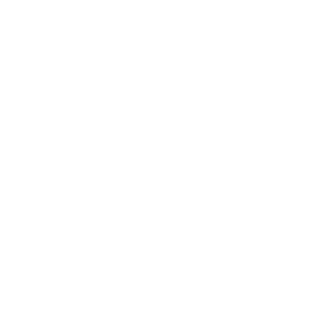

Using known structure for first tile

Step 1: canvas 64×64×16, tile center=(1,0), top-left=(32,16)


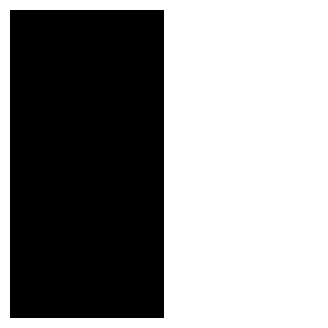


Step 2: canvas 64×64×16, tile center=(1,1), top-left=(32,32)


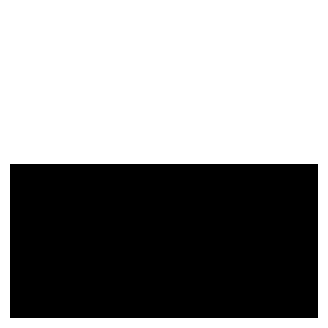


Step 3: canvas 64×64×16, tile center=(0,1), top-left=(16,32)


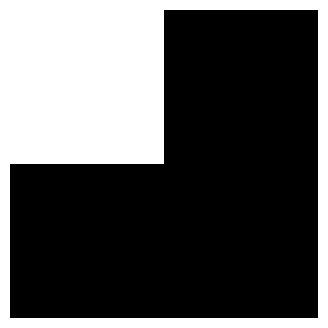

KeyboardInterrupt: 

In [153]:
canvas ,canvas_list, x_gt_list, mask_list= outpaint_square_spiral(structure_model,sched,3,device,start_with_known=True,split_big_known=split_big_known)

In [290]:
visualize_structure(canvas)

In [291]:
# for i in range(1,9,1):
    
#     visualize_structure(x_gt_list[i][0])
#     visualize_structure(mask_list[i][0])
#     visualize_structure(canvas_list[i])


In [292]:
x_gt_list[0].shape

torch.Size([1, 1, 32, 32, 16])

## 2. outpaint sem

In [293]:
torch.save(canvas, f"{KITTI_WEIGHTS}/canvas_start_with_known17.pt")

In [294]:
def construct_octree_dict(canvas, L, device):
    tile, stride, depth = 32, 16, 64

    steps = spiral_centers_halfstep(L-1)
    min_x = min(tx for tx,ty in steps)
    min_y = min(ty for tx,ty in steps)
    octree_dict = {}
    for i, (tx,ty) in enumerate(steps):
        # pixel coords for top-left of tile
        x0 = stride*(tx - min_x)
        y0 = stride*(ty - min_y)
        split_big = torch.zeros(1,1,32,32,32).cuda()
        split_big[:,:,:,:,0:16] = canvas[:,x0:x0+32,y0:y0+32,:]
        octree = split2octree_small(splitbig2split(split_big), 6, 4)
        octree_dict[tx,ty] = octree
    return octree_dict
        


In [295]:
# canvas = torch.load(f"{KITTI_WEIGHTS}/canvas_start_with_known.pt")

In [296]:
octree_dict = construct_octree_dict(canvas, 3,device)

In [297]:
def sem_paint_octree(octree_dict,x,y):
    
    octree_in_recon_outpaint = octree_dict[x,y].cuda()
    octree_out_recon_outpaint = vae.create_child_octree(octree_in_recon_outpaint).cuda()
    doctree_recon_outpaint = DualOctree(octree_out_recon_outpaint)
    doctree_recon_outpaint.post_processing_for_docnn()
    z_rand_outpaint = torch.randn(doctree_recon_outpaint.total_num, LATENT_DIM)
    z_T_outpaint = z_rand_outpaint.cuda()


    z_sampled_outpaint = ddim_sample_logsnr_cosine(
        z_T=z_T_outpaint,
        model=unet_model,
        doctree=doctree_recon_outpaint,
        S=  50
        
    )


    output = vae.decode_code(z_sampled_outpaint.cuda(), doctree_recon_outpaint, update_octree=False, pos=None)
    recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_dict[x,y].cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

    # visualize_kitti_instance(recon_voxel[0])
    return recon_voxel[0]

In [298]:
octree_dict[(0,0)].nnum

tensor([    1,     8,    64,   512,  4096,  6400, 31864], dtype=torch.int32)

In [299]:
octree_known.nnum

tensor([    1,     8,    64,   512,  4096,  6400, 31864], dtype=torch.int32)

In [300]:

import torch

# ---- helpers ---------------------------------------------------------------

def _block_coords(i0,i1,j0,j1,k0,k1, device):
    # (i,j,k) with ij-indexing to match your example
    ii, jj, kk = torch.meshgrid(
        torch.arange(i0, i1, device=device),
        torch.arange(j0, j1, device=device),
        torch.arange(k0, k1, device=device),
        indexing='ij'
    )
    coords = torch.stack([ii, jj, kk], dim=-1).reshape(-1, 3).to(torch.int32)
    return coords

@torch.no_grad()
def _copy_block_into(latent_dict,key,z_gt, mask, *,
                     dst_octree, dst_offset,
                     src_octree, src_offset,
                     src_box, dst_box,
                     batch_idx=0, depth_level=6):
    """
    Copy values from src half-block into dst half-block using octree index lookups.
    src_box/dst_box are (i0,i1,j0,j1,k0,k1) in *their respective* tile coordinate frames.
    """
    device = z_gt.device
    # Build coord list in src frame
    i0,i1,j0,j1,k0,k1 = src_box
    i2,i3,j2,j3,k2,k3 = dst_box
    coords_src = _block_coords(i0,i1,j0,j1,k0,k1, device=device)
    coords_dst = _block_coords(i2,i3,j2,j3,k2,k3, device=device)

    # Attach batch index (matches your code)
    xyzb_src = torch.cat([coords_src, torch.full((coords_src.shape[0],1), batch_idx, dtype=torch.int32, device=device)], dim=1)
    xyzb_dst = torch.cat([coords_dst, torch.full((coords_dst.shape[0],1), batch_idx, dtype=torch.int32, device=device)], dim=1)
    # Search both octrees
    idx_src = src_octree.search_xyzb(xyzb_src, depth=depth_level)
    idx_dst = dst_octree.search_xyzb(xyzb_dst, depth=depth_level)  # same spatial coords but in dst frame’s origin

    valid = (idx_src != -1) & (idx_dst != -1)
    z_src = latent_dict[key]
  
    if valid.any():
        z_gt[idx_dst[valid] + dst_offset] = z_src[idx_src[valid] + src_offset]
        mask[idx_dst[valid] + dst_offset] = 1

# ---- main “define mask & gt” logic per tile --------------------------------
def get_offset(vae,octree):

    octree_recon = vae.create_child_octree(octree).cuda()
    doctree = DualOctree(octree_recon)
    offset = doctree.total_num - doctree.nnum[6]
    return octree_recon,offset
def define_mask_and_gt_for_tile(vae,current_key, octree_dict, output_dict,visited_keys,
                                *, I=64, J=64, K=32, device="cuda"):
    """
    Returns (z_gt, mask) for the current tile at `current_key=(x,y)`,
    filled from any visited neighbors (left/right/top/bottom).
    Shapes match your outpaint latent layout.
    """
    # Extract handles for current tile
    cur_octree = octree_dict[current_key]
   
    octree_out_recon = vae.create_child_octree(cur_octree).cuda()
    cur_doctree = DualOctree(octree_out_recon)
    cur_octree_recon,cur_offset = get_offset(vae,cur_octree)
    # Preallocate
    z_rand_cur = torch.randn(cur_doctree.total_num, LATENT_DIM)
    z_gt  = torch.zeros_like(z_rand_cur, device=device)   # same flat storage type/shape
    mask  = torch.zeros_like(z_rand_cur, device=device)

    # neighbor keys
    x,y = current_key
    left_key   = (x-1, y)
    right_key  = (x+1, y)
    top_key    = (x,   y+1)
    bottom_key = (x,   y-1)
 
    # LEFT neighbor: copy its RIGHT half -> current LEFT half
    if left_key in visited_keys:
        nbr_octree = octree_dict[left_key]
        nbr_octree_recon,nbr_offset=get_offset(vae,nbr_octree)
        _copy_block_into(
            output_dict,left_key,
            z_gt, mask,
            dst_octree=cur_octree_recon,  dst_offset=cur_offset ,
            src_octree=nbr_octree_recon, src_offset=nbr_offset,
            src_box=(I//2, I, 0, J, 0, K),     # right half of LEFT neighbor
            dst_box=(0, I//2, 0, J, 0, K),     # left half of CURRENT
        )

    # RIGHT neighbor: copy its LEFT half -> current RIGHT half
    if right_key in visited_keys:
        nbr_octree = octree_dict[right_key]
        nbr_octree_recon,nbr_offset=get_offset(vae,nbr_octree)
        _copy_block_into(
            output_dict,right_key,
            z_gt, mask,
            dst_octree=cur_octree_recon,  dst_offset=cur_offset ,
            src_octree=nbr_octree_recon, src_offset=nbr_offset,
            src_box=(0, I//2, 0, J, 0, K),     # left half of RIGHT neighbor
            dst_box=(I//2, I, 0, J, 0, K),     # right half of CURRENT
        )

    # TOP neighbor: copy its BOTTOM half -> current TOP half
    if top_key in visited_keys:
        
        nbr_octree = octree_dict[top_key]
        nbr_octree_recon,nbr_offset=get_offset(vae,nbr_octree)
        _copy_block_into(
            output_dict,top_key,
            z_gt, mask,
            dst_octree=cur_octree_recon,  dst_offset=cur_offset ,
            src_octree=nbr_octree_recon, src_offset=nbr_offset,
            src_box=(0, I, 0, J//2, 0, K),     # bottom half of TOP neighbor
            dst_box=(0, I, J//2, J, 0, K),     # top half of CURRENT
        )

    # BOTTOM neighbor: copy its TOP half -> current BOTTOM half
    if bottom_key in visited_keys:
       
        nbr_octree = octree_dict[bottom_key]
        nbr_octree_recon,nbr_offset=get_offset(vae,nbr_octree)
        _copy_block_into(
            output_dict,bottom_key,
            z_gt, mask,
            dst_octree=cur_octree_recon,  dst_offset=cur_offset ,
            src_octree=nbr_octree_recon, src_offset=nbr_offset,
            src_box=(0, I, J//2, J, 0, K),     # top half of BOTTOM neighbor
            dst_box=(0, I, 0, J//2, 0, K),     # bottom half of CURRENT
        )

    return z_gt, mask


@torch.no_grad()
def ddim_sample_logsnr_cosine_inpaint(z_T,z_gt, model,mask, doctree, S=50, jump_n_sample = 10,predict_mode="x0"):
    """
    DDIM sampling using cosine logSNR schedule and x₀ prediction.

    Args:
        z_T: Initial noise tensor [N, C]
        model: Trained diffusion model
        doctree: DualOctree structure
        S: Number of DDIM steps (e.g., 50)
        predict_mode: "x0" (only supported here)
    """
    assert predict_mode == "x0", "Only x0 mode is supported in this version."

    # === Step 1: Generate continuous t schedule [1.0, ..., 0.0]
    t_steps = torch.linspace(1., 0., S + 1, device=z_T.device)  # [S+1]
    t_pairs = list(zip(t_steps[:-1], t_steps[1:]))


    z_t = z_T
    for t, t_next in t_pairs:
        # Convert scalars to tensors
        for j in range(jump_n_sample): 
            t_tensor = t.view(1, 1)
            t_next_tensor = t_next.view(1, 1)

            logsnr_t = alpha_cosine_log_snr(t_tensor)
            logsnr_next = alpha_cosine_log_snr(t_next_tensor)

            alpha_t, sigma_t = log_snr_to_alpha_sigma(logsnr_t)
            alpha_next, sigma_next = log_snr_to_alpha_sigma(logsnr_next)
            # Inpaint
            noised_z_gt = (z_gt * alpha_next + sigma_next * torch.randn_like(z_gt))
            x0_pred = model(z_t, doctree=doctree, timesteps=t_tensor)  # Predict x0
            x0_pred = ( mask) * noised_z_gt + (1-mask) * x0_pred
            # DDIM update rule
            z_t = alpha_next * x0_pred + sigma_next * torch.randn_like(z_t)
            if j < jump_n_sample - 1 and t > 1:
                noise_back = torch.randn_like(z_t)
                # noised_data = alpha_t * noised_data + sigma_t * noise_back
                z_t = alpha_t * z_t + sigma_t * noise_back
            
    return z_t


In [301]:


def outpaint_latent_canvas(unet_model,vae, octree_dict, L, device,start_with_known = False, latent_known = None):
    tile, stride, depth = 32, 16, 16
    L = 2*(tile + (L-1)*stride)
    latent_dict = {}
    recon_vox_dict = {}
    visited = set()
    i = 0
    for key, octree in octree_dict.items():
    
        print(i,key)
        # define mask and gt
        
        
        if start_with_known and key == (0,0):
            latent_dict[key] = z_sampled_known
        else:
            z_gt, mask = define_mask_and_gt_for_tile(vae,key, octree_dict,latent_dict, visited,
                                                I=64, J=64, K=32, device=device)

            
            
            # inoutpaint
            z_T = torch.randn_like(z_gt)
            octree_outpaint = vae.create_child_octree(octree).cuda()
            doctree_outpaint = DualOctree(octree_outpaint)
            doctree_outpaint.post_processing_for_docnn()
            z_sampled_outpaint = ddim_sample_logsnr_cosine_inpaint(z_T,z_gt, unet_model,mask,
                                                                doctree_outpaint, S=50,jump_n_sample=2, predict_mode="x0")
            
            output = vae.decode_code(z_sampled_outpaint.cuda(), doctree_outpaint, update_octree=False, pos=None)
            recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_dict[key].cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)
            recon_vox_dict[key] = recon_voxel
            latent_dict[key] = z_sampled_outpaint
   
        visited.add(key)
        i += 1
        # if i == 3:
        #     break

    return latent_dict, recon_vox_dict

In [302]:
for key, octree in octree_dict.items():

    print(key, octree)

(0, 0) <ocnn.octree.octree.Octree object at 0x7f69d8515310>
(1, 0) <ocnn.octree.octree.Octree object at 0x7f69d84f6290>
(1, 1) <ocnn.octree.octree.Octree object at 0x7f69284ae950>
(0, 1) <ocnn.octree.octree.Octree object at 0x7f69584877d0>
(-1, 1) <ocnn.octree.octree.Octree object at 0x7f69e16440d0>
(-1, 0) <ocnn.octree.octree.Octree object at 0x7f69702ca8d0>
(-1, -1) <ocnn.octree.octree.Octree object at 0x7f692849b450>
(0, -1) <ocnn.octree.octree.Octree object at 0x7f69583e9b90>
(1, -1) <ocnn.octree.octree.Octree object at 0x7f692849bf90>


In [303]:
latent_dict, recon_vox_dict = outpaint_latent_canvas(unet_model,vae, octree_dict, 3, device,start_with_known = True, latent_known = z_sampled_known)

0 (0, 0)
1 (1, 0)
2 (1, 1)
3 (0, 1)
4 (-1, 1)
5 (-1, 0)
6 (-1, -1)
7 (0, -1)
8 (1, -1)


In [304]:
canvas_sem = torch.zeros((512,512,32)).cuda()
canvas_sem[128:384,128:384,:] = recon_voxel
canvas_sem[384:512,128:384,:] = recon_vox_dict[(1,0)][0][128:256,:,:]

canvas_sem[384:512,384:512,:] = recon_vox_dict[(1,1)][0][128:256,128:256,:]
canvas_sem[128:384,384:512,:] = recon_vox_dict[(0,1)][0][:,128:256,:]
canvas_sem[0:128,256:512,:] = recon_vox_dict[(-1,1)][0][0:128,0:256,:]
canvas_sem[0:128,128:256,:] = recon_vox_dict[(-1,0)][0][0:128,0:128,:]
canvas_sem[0:256,0:128,:] = recon_vox_dict[(-1,-1)][0][0:256,0:128,:]
canvas_sem[256:384,0:128,:] = recon_vox_dict[(0,-1)][0][128:256,0:128,:]
canvas_sem[384:512,0:128,:] = recon_vox_dict[(1,-1)][0][128:256,0:128,:]

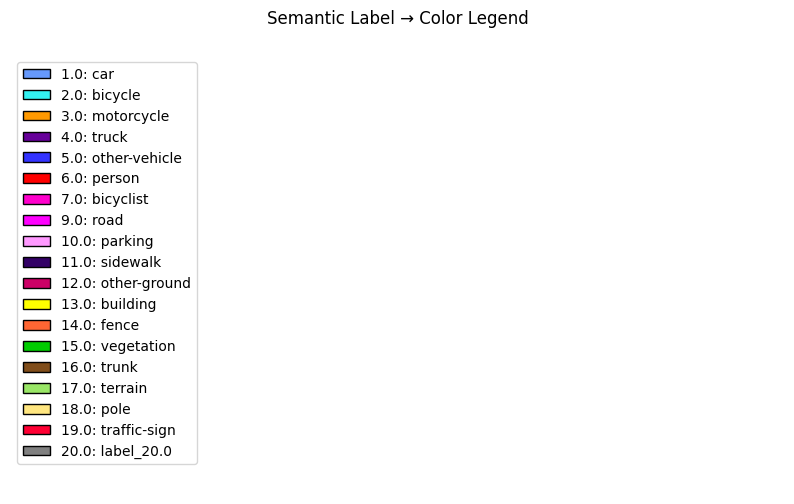

In [305]:
visualize_kitti_instance(canvas_sem)

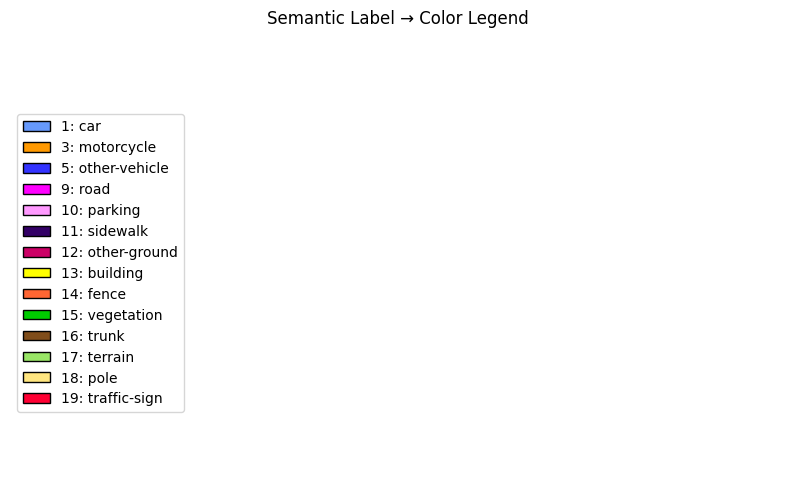

In [158]:
visualize_kitti_instance(recon_vox_dict[(1,1)][0])

In [168]:
octree = octree_dict[(1,1)].cuda()
octree_outpaint = vae.create_child_octree(octree).cuda()
doctree_outpaint = DualOctree(octree_outpaint)
z_T = torch.randn(doctree_outpaint.total_num, LATENT_DIM).cuda()

doctree_outpaint.post_processing_for_docnn()
z_sampled_outpaint = ddim_sample_logsnr_cosine(z_T,unet_model,
                                                doctree_outpaint, S=30,predict_mode="x0")

output = vae.decode_code(z_sampled_outpaint.cuda(), doctree_outpaint, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

<env:octfusion>/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


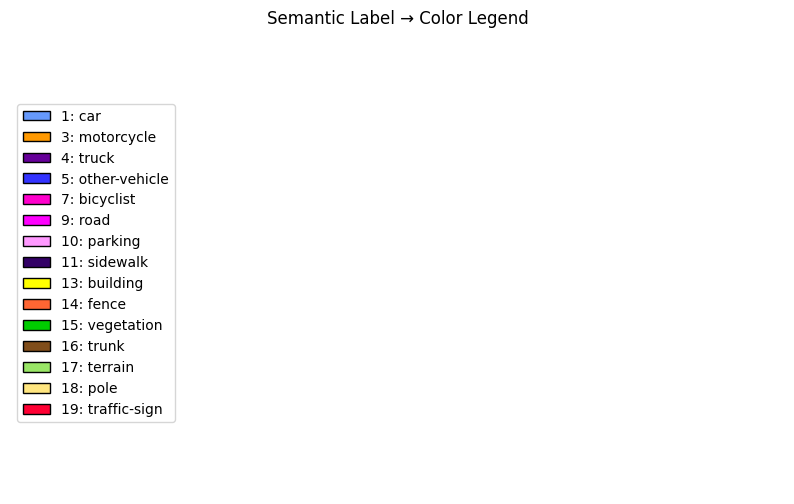

In [169]:
visualize_kitti_instance(recon_voxel[0])

In [179]:
sem_canvas = torch.zeros((256*2,256*2,32)).cuda()

sem_canvas[0:256,0:256,:] = sem_paint_octree(octree_dict,-1,-1)
sem_canvas[0:256,256:512,:] = sem_paint_octree(octree_dict,-1,1)
sem_canvas[256:512,256:512,:] = sem_paint_octree(octree_dict,1,1)
sem_canvas[256:512,0:256,:] = sem_paint_octree(octree_dict,-1,1)

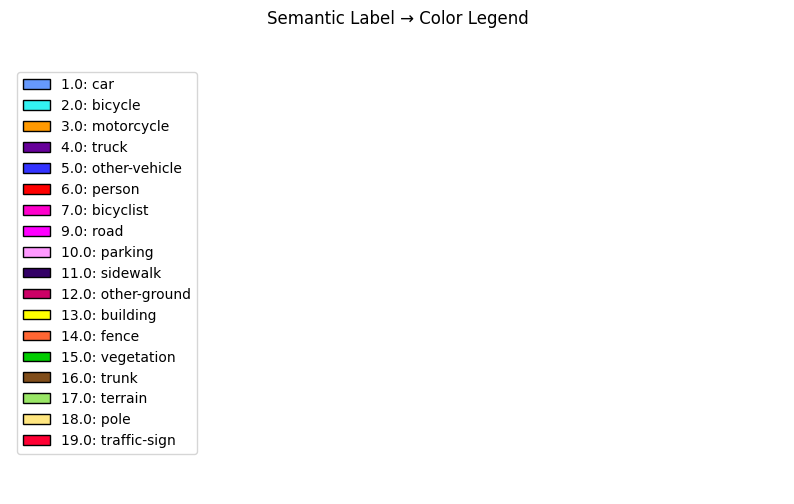

In [180]:
visualize_kitti_instance(sem_canvas)

In [235]:
visualize_structure(canvas)

# start with a known canvas

In [258]:
canvas = torch.load(f"{KITTI_WEIGHTS}/canvas_start_with_known16.pt")
visualize_structure(canvas)

/tmp/ipykernel_339332/2004106976.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  canvas = torch.load("canvas_start_with_known16.pt")


In [259]:
# sem_canvas = torch.zeros((256*2,256*2,32)).cuda()

# sem_canvas[0:256,0:256,:] = sem_paint_octree(octree_dict,-1,-1)
# sem_canvas[0:256,256:512,:] = sem_paint_octree(octree_dict,-1,1)
# sem_canvas[256:512,256:512,:] = sem_paint_octree(octree_dict,1,1)
# sem_canvas[256:512,0:256,:] = sem_paint_octree(octree_dict,1,-1)
# visualize_kitti_instance(sem_canvas)

0 (0, 0)
1 (1, 0)
2 (1, 1)
3 (0, 1)
4 (-1, 1)
5 (-1, 0)
6 (-1, -1)
7 (0, -1)
8 (1, -1)


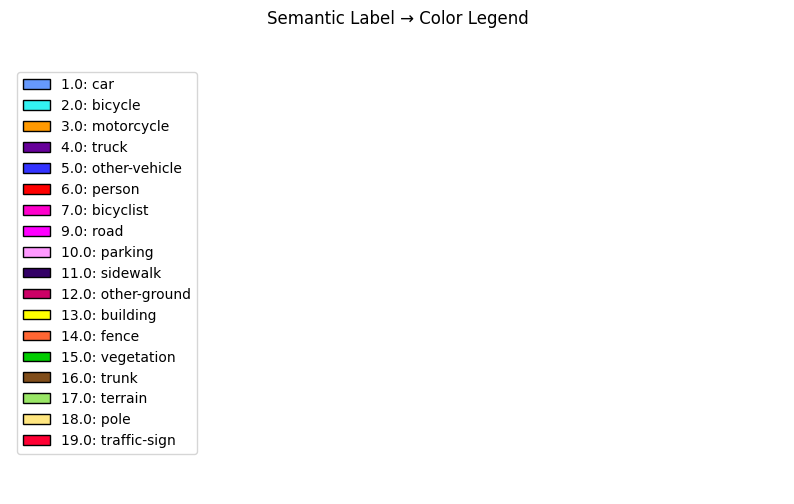

In [260]:
octree_dict = construct_octree_dict(canvas, 3,device)
octree_known = octree_dict[(0,0)]
octree_known_recon = vae.create_child_octree(octree_known).cuda()
doctree = DualOctree(octree_known_recon )
doctree.post_processing_for_docnn()
z_rand = torch.randn(doctree.total_num, LATENT_DIM)
z_T = z_rand.cuda()


z_sampled_known = ddim_sample_logsnr_cosine(
    z_T=z_T,
    model=unet_model,
    doctree=doctree,
    S=50,
    
)


output = vae.decode_code(z_sampled_known.cuda(), doctree, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_known.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

gt[gt != 0] = 20
# visualize_kitti_instance(torch.tensor(gt).cuda())
# visualize_kitti_instance(recon_voxel[0])
latent_dict, recon_vox_dict = outpaint_latent_canvas(unet_model,vae, octree_dict, 3, device,start_with_known = True, latent_known = z_sampled_known)
canvas_sem = torch.zeros((512,512,32)).cuda()
canvas_sem[128:384,128:384,:] = recon_voxel
canvas_sem[384:512,128:384,:] = recon_vox_dict[(1,0)][0][128:256,:,:]

canvas_sem[384:512,384:512,:] = recon_vox_dict[(1,1)][0][128:256,128:256,:]
canvas_sem[128:384,384:512,:] = recon_vox_dict[(0,1)][0][:,128:256,:]
canvas_sem[0:128,256:512,:] = recon_vox_dict[(-1,1)][0][0:128,0:256,:]
canvas_sem[0:128,128:256,:] = recon_vox_dict[(-1,0)][0][0:128,0:128,:]
canvas_sem[0:256,0:128,:] = recon_vox_dict[(-1,-1)][0][0:256,0:128,:]
canvas_sem[256:384,0:128,:] = recon_vox_dict[(0,-1)][0][128:256,0:128,:]
canvas_sem[384:512,0:128,:] = recon_vox_dict[(1,-1)][0][128:256,0:128,:]
visualize_kitti_instance(canvas_sem)